# Exploratory Data Analysis

The objective of this phase is to understand how customers use their accounts over time by analyzing transaction behavior at a monthly,account-level granualrity.

This analysis focuses on identifying usage intensity, cash flow patterns, and behavioral stability, which will later support financial health scoring and customer segmentation.

### Data Preparation

In [3]:
import pandas as pd

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/transactions_clean.csv")
df["transaction_datetime"] = pd.to_datetime(df["transaction_datetime"])

# Create year_month column
df["year_month"] = df["transaction_datetime"].dt.to_period("M").astype(str)

df.head()

,Date,Timestamp,Account No,Balance,Amount,Third Party Account No,Third Party Name,transaction_datetime,year_month
0,01/01/2025,00:00,839964633,3385.0,2602.0,NaN,Boots,2025-01-01,2025-01
1,01/01/2025,00:00,793069740,3318.0,2780.0,NaN,Mountain Warehouse,2025-01-01,2025-01
2,01/01/2025,00:00,793069740,2278.0,-1040.0,705519819.0,NaN,2025-01-01,2025-01
3,01/01/2025,00:00,705519819,2726.0,1040.0,793069740.0,NaN,2025-01-01,2025-01
4,01/01/2025,00:00,726302171,3253.5,1542.5,NaN,Craftastic,2025-01-01,2025-01


To enable time-based behavioral analysis, transaction timestamps were transformed into a year-month format.

This allows aggregation of transaction activity at a monthly level, which aligns with common financial reporting cycles and provides a balance between behvioral signal and noise reduction.

At this stage, missing values in merchant or counterparty fields are intentionally preserved, as they encode transaction type (merchant payment vs P2P transfer).

### Inflow and Outflow Identification
Transaction direction is derived from the sign of the transaction amount:
* Positive values represent cash inflows
* Negative values represent cash outflows

Explicit inflow and outflow columns are created to improve readability and to support downstream aggregation of cash flow metrics.

In [6]:
# Define inflows vs outflows
df["inflow"] = df["Amount"].where(df["Amount"] > 0, 0)
df["outflow"] = df["Amount"].where(df["Amount"] < 0, 0)

### Monthly Account-Level Aggregation
Transactions are aggregated at an account-month level to capture recurring behavioral patterns while smoothing day-to-day noise.

The following metrics are computed for each account and month:
* `txn_count` - Transaction frequency
* `total_inflow`, `total_outflow` - Total inflows and outflows 
* `avg_txn_amount` - Average transaction amount 
* `balance_std` - Balance volatility 
* `unique_merchants` - Merchant diversity 

In [8]:
# Monthly Account-level Aggregation
monthly_account = (
    df.groupby(["Account No", "year_month"])
      .agg(
          txn_count=("Amount", "count"),
          total_inflow=("inflow", "sum"),
          total_outflow=("outflow", "sum"),
          avg_txn_amount=("Amount", "mean"),
          balance_std=("Balance", "std"),
          unique_merchants=("Third Party Name", "nunique")
      )
      .reset_index()
)
monthly_account.head()

,Account No,year_month,txn_count,total_inflow,total_outflow,avg_txn_amount,balance_std,unique_merchants
0,100100738,2025-01,17,0.0,-1192.90,-70.170588,495.643012,7
1,100100738,2025-02,9,0.0,-834.03,-92.670000,313.924862,7
2,100100738,2025-03,3,0.0,-155.98,-51.993333,132.771179,2
3,100100738,2025-04,3,0.0,-241.83,-80.610000,557.072221,2
4,100100738,2025-05,1,0.0,-110.52,-110.520000,NaN,1


In [9]:
monthly_account.to_csv(
    "../outputs/account_month_metrics.csv",
    index=False
)

Missing values observed in aggregated metrics are intentional and informative rather than indicative of poor data quality.

For example:
* Balance volatility is undefined for account-month combinations with a single transaction
* Merchant-related fields may be missing for P2P transfers

These missing values are preserved during exploratory analysis to retain behavioral meaning and will be handled contextually during modeling or dashboard presentation when appropriate.

### How active are customers over time?
* Indicates customer engagement
* Helps identify power users vs dormant accounts

In [12]:
# Monthly Transaction volume
monthly_txn_volume = (
    monthly_account.groupby("year_month")["txn_count"]
    .sum()
    .reset_index()
)

monthly_txn_volume

,year_month,txn_count
0,2025-01,28900
1,2025-02,8747
2,2025-03,7735
3,2025-04,7877
4,2025-05,7436
5,2025-06,7714
6,2025-07,7436
7,2025-08,7305
8,2025-09,6851
9,2025-10,6394


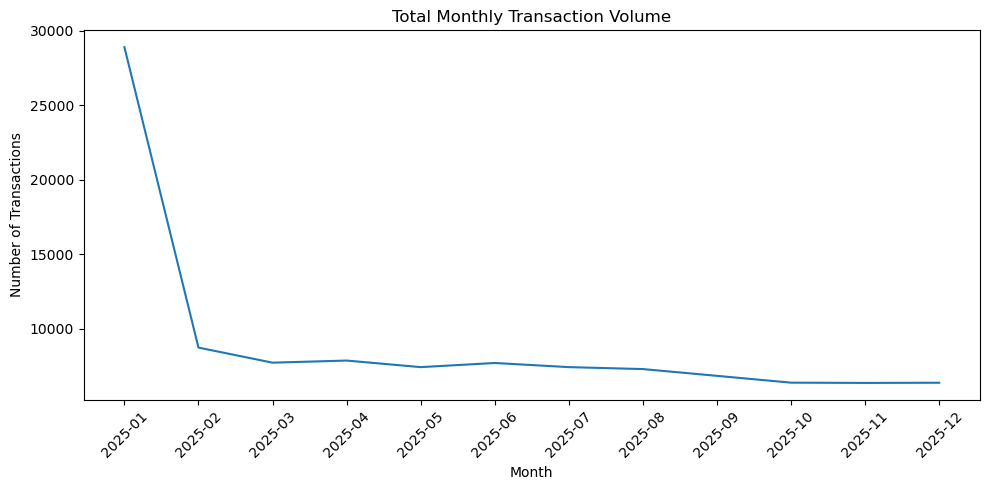

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_txn_volume["year_month"], monthly_txn_volume["txn_count"])
plt.xticks(rotation=45)
plt.title("Total Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

This analysis examines how transaction volume evolves over time to assess overall customer engagement.

A significant spike in transaction volume is observed in Jan, followed by a stabilization in subsequent months. This pattern is consistent with account onboarding effects or initial funding activity and does not indicate data inconsistency.

After the initial month, transaction activity remains relatively stable, suggesting sustained and consistent usage across the customer base.

### Are customers primarily spending or receiving money?
* Financial health
* Liquidity patterns
* Risk assessment

In [16]:
# Inflows vs Outflows
monthly_cashflow = (
    monthly_account.groupby("year_month")
    .agg(
        total_inflow=("total_inflow", "sum"),
        total_outflow=("total_outflow", "sum")
    )
    .reset_index()
)

monthly_cashflow


,year_month,total_inflow,total_outflow
0,2025-01,9464388.26,-6731152.94
1,2025-02,49860.00,-572768.27
2,2025-03,31130.00,-481565.73
3,2025-04,47870.00,-524225.88
4,2025-05,15090.00,-447389.84
5,2025-06,72930.00,-516785.44
6,2025-07,41430.00,-485172.01
7,2025-08,25890.00,-446817.95
8,2025-09,45200.00,-404593.36
9,2025-10,11610.00,-374059.36


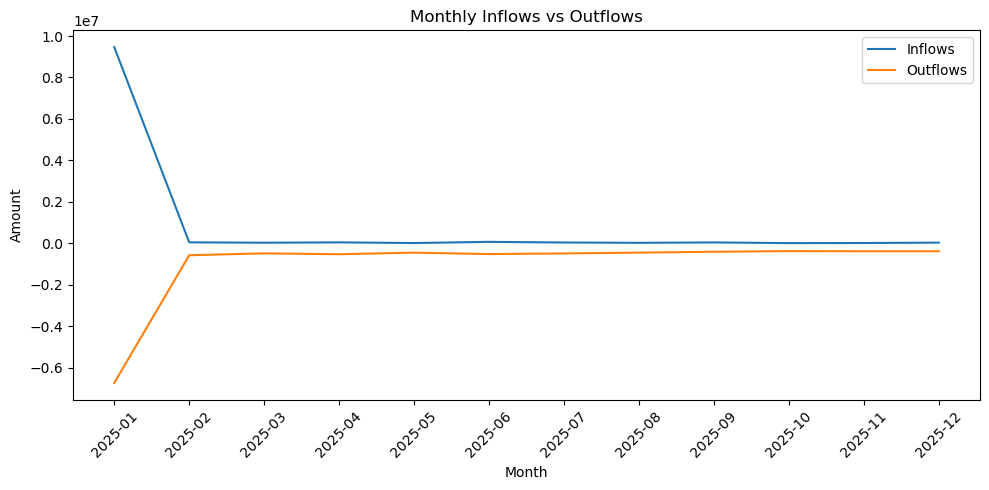

In [17]:
plt.figure(figsize=(10,5))
plt.plot(monthly_cashflow["year_month"], monthly_cashflow["total_inflow"], label="Inflows")
plt.plot(monthly_cashflow["year_month"], monthly_cashflow["total_outflow"], label="Outflows")
plt.xticks(rotation=45)
plt.title("Monthly Inflows vs Outflows")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()
plt.tight_layout()
plt.show()

This section compares total monthly inflows and outflows to understand customer cash flow dynamics.

Jan exhibits substantially higher inflows and outflows, likely driven by initial account funding. In later months, outflows consistently exceed inflows, indicating that many customers rely on previous accumulated balances rather than recurring income streams.

This behavior highlights potential liquidity risk for certain users and motivates the need for financial health scoring in later phases.

### SUMMARY
* Customer transaction behavior shows strong initial activity followed by stable engagement
* Cash flow patterns indicate reliance on early funding and sustained spending behavior
* Behavioral variability differs significantly across accounts
* Observed missing values reflect behavioral structure rather than data issues

These insights provide a strong foundation for deeper behavioral analysis and the development of a financial health scoring framework.

# Advanced Behavioral Analysis
### Transaction Amount Distribution

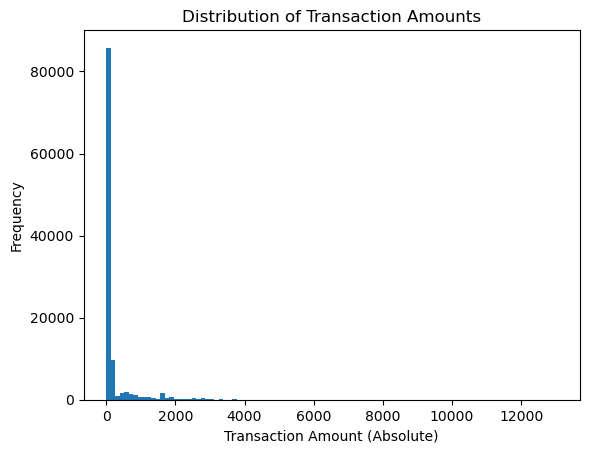

In [21]:
# Absolute transaction size for distribution analysis
df['abs_amount'] = df['Amount'].abs()

plt.figure()
plt.hist(df['abs_amount'], bins=100)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount (Absolute)')
plt.ylabel('Frequency')
plt.show()


#### Obeservation
Transaction amounts are **highly right-skewed**:
* Majority of transactions are small
* A small number of very large transactions drive volume

#### Interpretation
Typical consumer spending dominates usage, with occasional **high-impact events**.

#### Business implication
* Averages alone are misleading
* Risk systems should treat large transactions separately

### High-Value Transaction Identification (95th Percentile)

In [24]:
# Calculate high-value threshold
high_value_threshold = df['abs_amount'].quantile(0.95)

# Flag high-value transactions
df['high_value_txn'] = df['abs_amount'] >= high_value_threshold

# Summary
df['high_value_txn'].value_counts()


high_value_txn
False    103702
True       5458
Name: count, dtype: int64

In [25]:
df[df['high_value_txn']].groupby('year_month')['Amount'].agg(
    txn_count='count',
    total_amount='sum'
)


,txn_count,total_amount
year_month,,
2025-01,5259,8368451.26
2025-02,26,-10590.00
2025-03,13,6240.00
2025-04,33,-12640.00
2025-05,8,-5790.00
2025-06,45,-9790.00
2025-07,27,790.00
2025-08,9,1480.00
2025-09,12,20250.00


#### Definition
High-value transactions were defined using percentile-based threshold.

#### Observation 
* Only ~5% of transactions qualify as high-value
* Jan dominates high-value transaction volume

#### Business implication
High-value transactions may represent:
* Salary credits
* Rent payments
* Exceptional purchases

These events are critical for **risk monitoring and anomaly detection**.

### Balance Stability & Volatility
#### Monthly Balance Volatility per Account

In [28]:
balance_volatility = (
    df.groupby(['Account No', 'year_month'])['Balance']
      .std()
      .reset_index(name='balance_std')
)

balance_volatility.head()


,Account No,year_month,balance_std
0,100100738,2025-01,495.643012
1,100100738,2025-02,313.924862
2,100100738,2025-03,132.771179
3,100100738,2025-04,557.072221
4,100100738,2025-05,NaN


#### Observation
Balance volatility varies significantly by month and account, with some periods showing extreme instability.

#### Interpretation
High volatility may indicate:
* Income inconsistency
* Poor cash flow planning
* Financial stress

#### Business implication
Balance volatility is a **key input** for financial health and risk models.

#### Average Balance vs Volatility

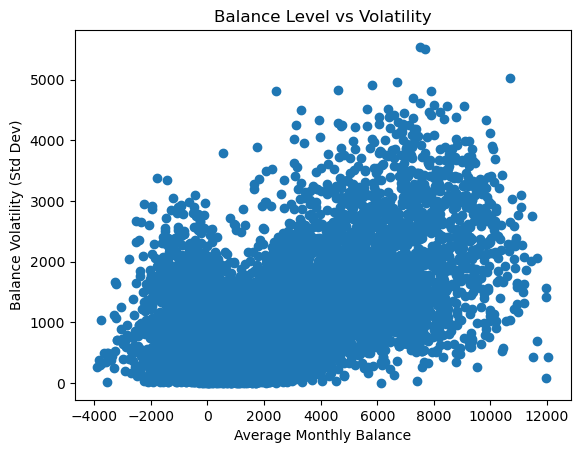

In [31]:
balance_stats = (
    df.groupby(['Account No', 'year_month'])
      .agg(
          avg_balance=('Balance', 'mean'),
          balance_std=('Balance', 'std')
      )
      .reset_index()
)

plt.figure()
plt.scatter(balance_stats['avg_balance'], balance_stats['balance_std'])
plt.xlabel('Average Monthly Balance')
plt.ylabel('Balance Volatility (Std Dev)')
plt.title('Balance Level vs Volatility')
plt.show()


#### Observation
Higher average balances tend to show **higher absolute volatility**, but with wide dispersion.

#### Interpretation
Wealthier users transact more, but stability varies widely.

#### Business implications
Balance size alone does not equal financial health - **behavior matters**

### Temporal Spending Behavior
#### Time-of-Day Analysis

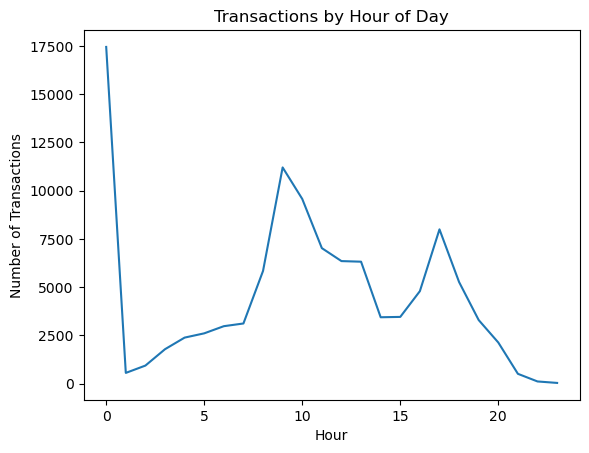

In [34]:
# Extract hour
df['hour'] = df['transaction_datetime'].dt.hour

hourly_activity = df.groupby('hour').size()

plt.figure()
hourly_activity.plot(kind='line')
plt.title('Transactions by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Transactions')
plt.show()


#### Observation
Clear transaction peaks occur:
* Morning (9-11 AM)
* Evening (5-7 PM)

#### Interpretation
Usage aligns with **daily routines** rather than overnight activity

#### Business implication
System maintenance, alerts, and product nudges should align with peak usage windows.

#### Weekday or Weekend Transaction

In [37]:
df['weekday'] = df['transaction_datetime'].dt.weekday
df['is_weekend'] = df['weekday'] >= 5

weekday_vs_weekend = df.groupby('is_weekend').size()
weekday_vs_weekend


is_weekend
False    78069
True     31091
dtype: int64

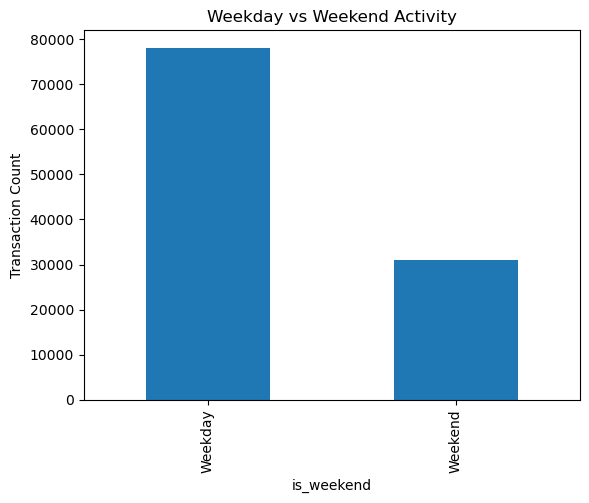

In [38]:
weekday_vs_weekend.plot(kind='bar')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.ylabel('Transaction Count')
plt.title('Weekday vs Weekend Activity')
plt.show()


#### Observation
Approximately **70% of transactions occur on weekdays**.

#### Interpretation
Spending is tied more to routine activity than discretionary weekend behavior.

#### Business implication
This pattern supports targeting:
* Weekday budgeting tools
* Salary-linked financial products

### Merchant & Counterparty Diversity
#### Merchant Diversity per Account-Month

In [41]:
merchant_diversity = (
    df.groupby(['Account No', 'year_month'])['Third Party Name']
      .nunique()
      .reset_index(name='unique_merchants')
)

merchant_diversity.head()


,Account No,year_month,unique_merchants
0,100100738,2025-01,7
1,100100738,2025-02,7
2,100100738,2025-03,2
3,100100738,2025-04,2
4,100100738,2025-05,1


#### Observation
Merchant diversity declines over time for some accounts.

#### Interpretation
Users may be:
* Reducing spending
* Narrowing purchases to essentials

#### Business implication
Declining merchant diversity can signal **financial tightening** or churn risk.

#### Peer-to-Peer vs Merchant Transactions

In [44]:
import numpy as np

df['txn_type'] = np.where(
    df['Third Party Account No'].notna(),
    'Peer-to-Peer',
    'Merchant'
)

txn_type_summary = (
    df.groupby('txn_type')['Amount']
      .agg(
          txn_count='count',
          avg_amount='mean',
          total_amount='sum'
      )
)

txn_type_summary


,txn_count,avg_amount,total_amount
txn_type,,,
Merchant,107883,-17.116169,-1846543.61
Peer-to-Peer,1277,-34.348692,-43863.28


#### Observation
* Merchant transactions dominate volume
* Peer-to-peer transactions are fewer but meaningful

#### Interpretation
The platform is primarily used for **consumer spending**, with limited social transfer usage.

#### Business implication
P2P features may be underutilised - representing a **product growth opportunity**.